# TP3 – Interprétabilité : cartes de saillance et Grad-CAM

Objectif : analyser visuellement ce que regarde le réseau lorsqu’il prend
sa décision de classification, en utilisant :

- les **cartes de saillance** (saliency maps),
- la méthode **Grad-CAM** (Gradient-weighted Class Activation Mapping).

Nous utiliserons un des modèles déjà entraînés dans le TP2 (ici : CNN sur CIFAR-10).
Nous travaillerons sur des images du jeu de test et nous visualiserons :

- l'image originale,
- la carte de saillance / la heatmap Grad-CAM,
- une superposition (overlay) image + heatmap.

Nous comparerons ce que le modèle regarde pour les images bien classées
et pour les images mal classées.


🔹 Partie 2 – Préparation : vérifier le modèle et les données

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Charger CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalisation [0,1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("x_train_norm shape :", x_train_norm.shape)
print("x_test_norm shape  :", x_test_norm.shape)
print("y_train shape      :", y_train.shape)
print("y_test shape       :", y_test.shape)

# Classes
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


x_train_norm shape : (50000, 32, 32, 3)
x_test_norm shape  : (10000, 32, 32, 3)
y_train shape      : (50000,)
y_test shape       : (10000,)


recréer le CNN (exact même modèle que TP2)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# CNN (même TP2)
model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entraînement rapide
history_cnn = model_cnn.fit(
    x_train_norm, y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64
)

# Évaluation
test_loss, test_acc = model_cnn.evaluate(x_test_norm, y_test)
print(f"Test accuracy: {test_acc:.4f}")


c:\Users\Zz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.4309 - loss: 1.5798 - val_accuracy: 0.4972 - val_loss: 1.4531
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5682 - loss: 1.2277 - val_accuracy: 0.5948 - val_loss: 1.1557
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.6203 - loss: 1.0855 - val_accuracy: 0.6454 - val_loss: 1.0256
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6540 - loss: 0.9952 - val_accuracy: 0.6376 - val_loss: 1.0501
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6766 - loss: 0.9323 - val_accuracy: 0.6454 - val_loss: 1.0048
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6444 - loss: 1.0268
Test accuracy: 0.6444


In [3]:
model_cnn.save("cnn_cifar10_tp3.h5")
print("Modèle CNN sauvegardé ✓")


Modèle CNN sauvegardé ✓


In [4]:
model_cnn = tf.keras.models.load_model("cnn_cifar10_tp3.h5")


Vérifier (prédiction rapide)

In [5]:
import numpy as np

pred = model_cnn.predict(x_test_norm[:5]).argmax(axis=1)
print("Predictions:", pred)
print("True labels:", y_test[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
Predictions: [3 8 8 8 6]
True labels: [3 8 8 0 6]


Charger CIFAR-10 et normaliser (TP3 notebook)

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1) Chargement du dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# On aplati les labels (de (N,1) -> (N,))
y_train = y_train.flatten()
y_test = y_test.flatten()

# 2) Normalisation des images en [0,1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

print("x_train_norm shape :", x_train_norm.shape)
print("x_test_norm shape  :", x_test_norm.shape)
print("y_train shape      :", y_train.shape)
print("y_test shape       :", y_test.shape)

# 3) Noms des classes
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]



x_train_norm shape : (50000, 32, 32, 3)
x_test_norm shape  : (10000, 32, 32, 3)
y_train shape      : (50000,)
y_test shape       : (10000,)


Étape 2 – Redéfinir le CNN (même que TP2)

In [7]:
from tensorflow.keras import layers, models

# 1) Définition du CNN (comme dans le TP2)
model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 2) Compilation
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3) Résumé du modèle
model_cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Entraîner le CNN (quelques epochs)

In [8]:
# ==========================================
# Entraînement rapide du CNN pour TP3
# ==========================================

history_cnn = model_cnn.fit(
    x_train_norm, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Évaluation sur le test
test_loss, test_acc = model_cnn.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nAccuracy test (CNN TP3) : {test_acc*100:.2f}%")
print(f"Loss test (CNN TP3)     : {test_loss:.4f}")


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.4412 - loss: 1.5530 - val_accuracy: 0.5466 - val_loss: 1.2877
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5691 - loss: 1.2187 - val_accuracy: 0.6070 - val_loss: 1.1248
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6173 - loss: 1.0897 - val_accuracy: 0.6352 - val_loss: 1.0337
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6513 - loss: 1.0005 - val_accuracy: 0.6516 - val_loss: 1.0042
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6736 - loss: 0.9348 - val_accuracy: 0.6608 - val_loss: 0.9823

Accuracy test (CNN TP3) : 64.67%
Loss test (CNN TP3)     : 1.0276


In [18]:
model_cnn.save("cnn_cifar10_tp3.h5")
print("Modèle CNN sauvegardé sous cnn_cifar10_tp3.h5")


Modèle CNN sauvegardé sous cnn_cifar10_tp3.h5


Étape 5 – Sélectionner 20 images de test

In [19]:
# ==========================================
# Sélection de 20 images de test
# ==========================================

num_samples = 20
indices = np.random.choice(len(x_test_norm), num_samples, replace=False)

x_sample = x_test_norm[indices]   # (20, 32, 32, 3)
y_sample = y_test[indices]        # (20,)

# Prédictions du CNN
pred_probs = model_cnn.predict(x_sample)
pred_labels = np.argmax(pred_probs, axis=1)
confidences = np.max(pred_probs, axis=1)

for i in range(num_samples):
    print(f"{i:02d} | True: {class_names[y_sample[i]]:10s} | "
          f"Pred: {class_names[pred_labels[i]]:10s} | "
          f"Conf: {confidences[i]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
00 | True: truck      | Pred: truck      | Conf: 0.75
01 | True: deer       | Pred: deer       | Conf: 0.74
02 | True: airplane   | Pred: airplane   | Conf: 0.68
03 | True: dog        | Pred: dog        | Conf: 0.27
04 | True: ship       | Pred: ship       | Conf: 0.90
05 | True: horse      | Pred: horse      | Conf: 0.38
06 | True: frog       | Pred: frog       | Conf: 0.42
07 | True: dog        | Pred: cat        | Conf: 0.43
08 | True: frog       | Pred: frog       | Conf: 0.94
09 | True: bird       | Pred: deer       | Conf: 0.39
10 | True: airplane   | Pred: airplane   | Conf: 0.51
11 | True: cat        | Pred: cat        | Conf: 0.27
12 | True: cat        | Pred: cat        | Conf: 0.73
13 | True: automobile | Pred: frog       | Conf: 0.28
14 | True: airplane   | Pred: airplane   | Conf: 0.68
15 | True: deer       | Pred: airplane   | Conf: 0.28
16 | True: dog        | Pred: horse      | Conf: 0.48
17 | True: truck      | Pred: dog        | 

Étape 6 – Fonction pour calculer une saliency map

On définit une fonction qui, pour une image, calcule :

le gradient de la classe prédite par rapport à l’image d’entrée,

et retourne une carte 2D normalisée.

In [20]:
# ==========================================
# Fonction : carte de saillance pour 1 image
# ==========================================

def compute_saliency_map(model, image):
    """
    image : numpy array (32,32,3) en [0,1]
    Retour :
      - saliency : (32,32) en [0,1]
      - class_idx : classe prédite utilisée pour le gradient
    """
    img = tf.convert_to_tensor(image[None, ...])  # (1,32,32,3)

    with tf.GradientTape() as tape:
        tape.watch(img)
        preds = model(img)              # (1,10)
        class_idx = tf.argmax(preds[0])
        class_score = preds[0, class_idx]

    grads = tape.gradient(class_score, img)[0]   # (32,32,3)

    # Importance max sur les canaux RGB
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)  # (32,32)

    # Normalisation [0,1]
    min_val = tf.reduce_min(saliency)
    max_val = tf.reduce_max(saliency)
    saliency = (saliency - min_val) / (max_val - min_val + 1e-8)

    return saliency.numpy(), int(class_idx.numpy())


Étape 7 – Calculer les saliency maps pour les 20 images

In [21]:
# ==========================================
# Calcul des saliency maps pour nos 20 images
# ==========================================

saliency_maps = []
used_class_idx = []

for i in range(num_samples):
    sal, cls = compute_saliency_map(model_cnn, x_sample[i])
    saliency_maps.append(sal)
    used_class_idx.append(cls)

saliency_maps = np.array(saliency_maps)
used_class_idx = np.array(used_class_idx)

print("saliency_maps shape :", saliency_maps.shape)


saliency_maps shape : (20, 32, 32)


Étape  – Afficher Original / Saliency / Overlay (10 par page)

On va afficher les 20 images en 2 fois, 10 par figure.

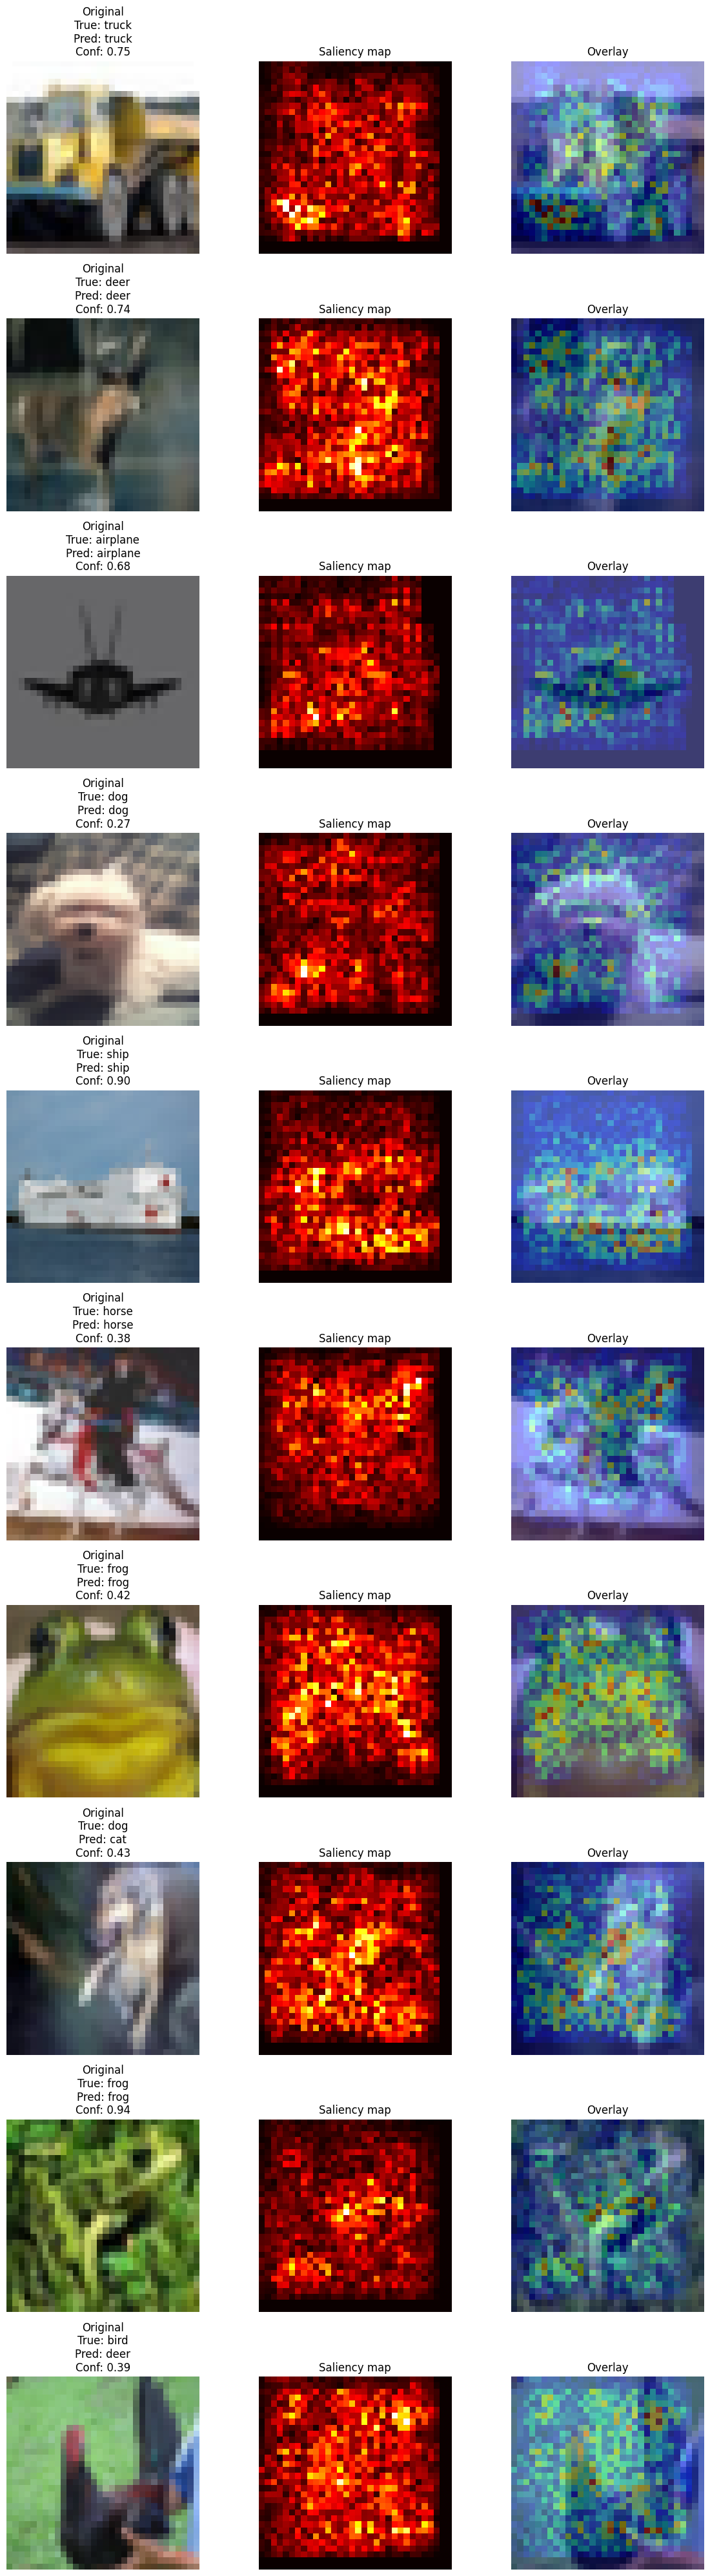

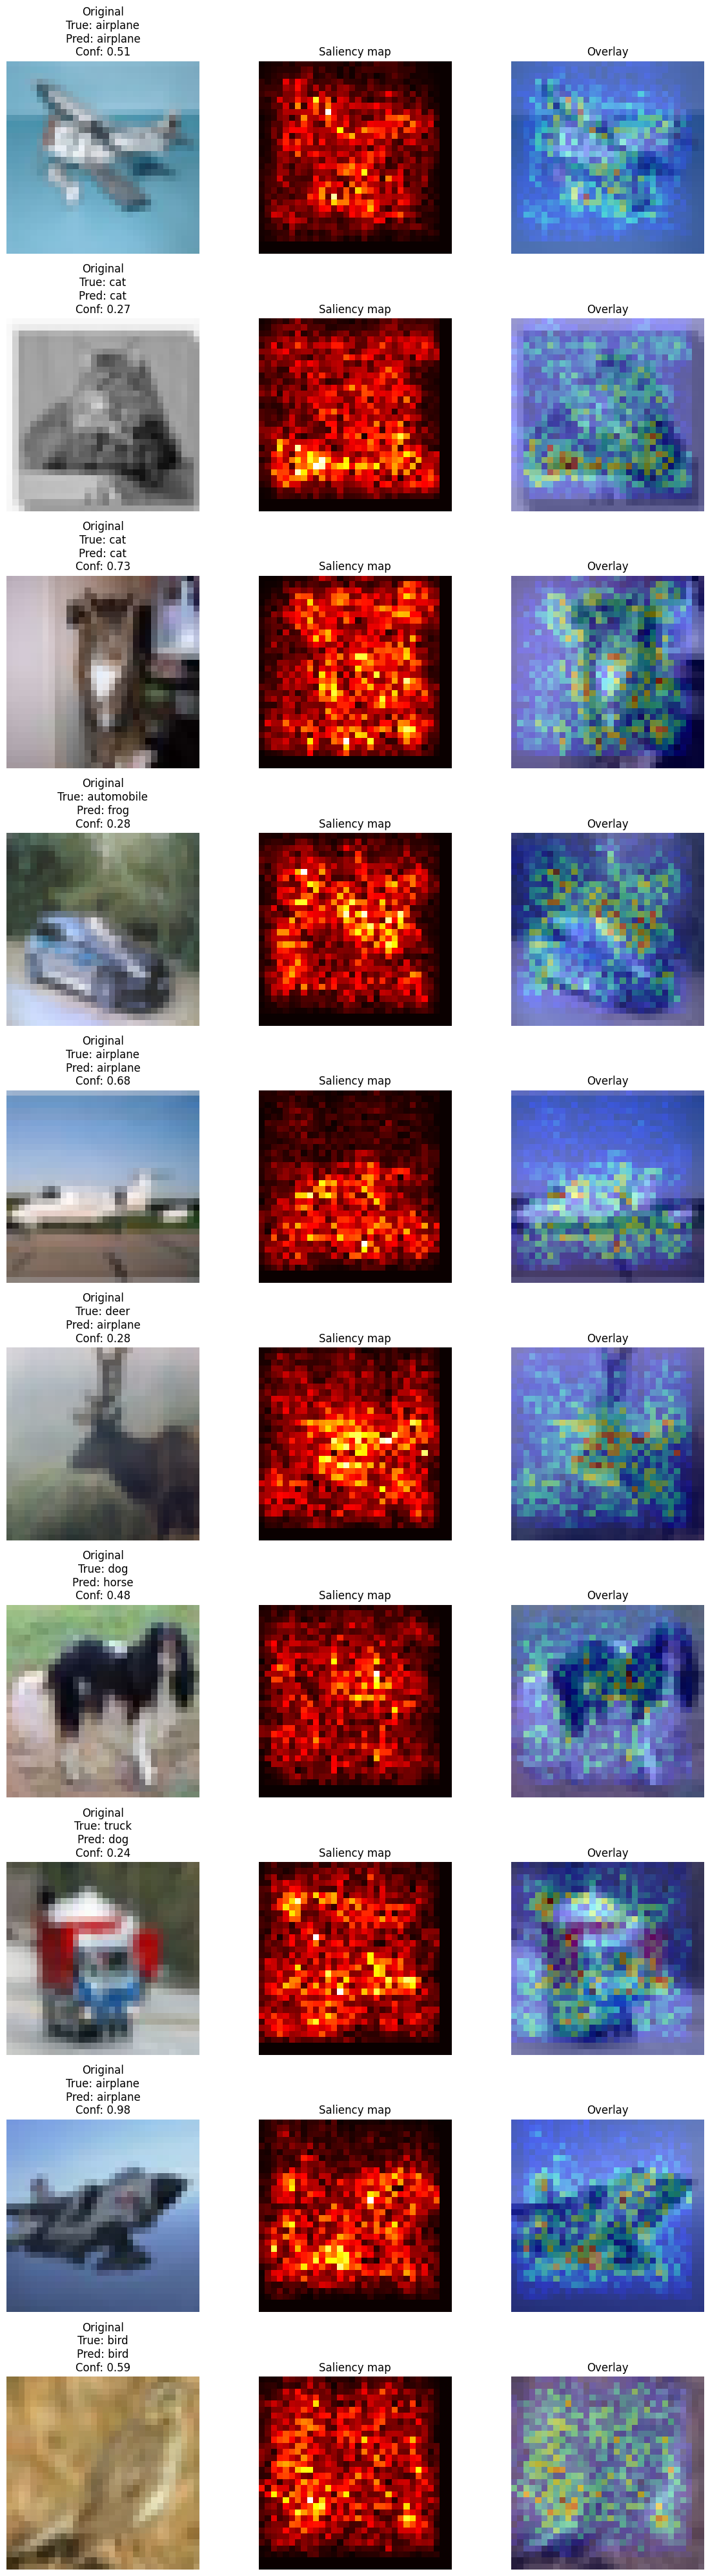

In [22]:
# ==========================================
# Affichage : Original / Saliency / Overlay
# ==========================================

def show_saliency_triplets(start_idx=0, count=10):
    end_idx = min(start_idx + count, num_samples)
    n = end_idx - start_idx

    plt.figure(figsize=(12, 4 * n))

    for i, idx in enumerate(range(start_idx, end_idx)):
        img = x_sample[idx]
        sal = saliency_maps[idx]
        true_label = class_names[y_sample[idx]]
        pred_label = class_names[pred_labels[idx]]
        conf = confidences[idx]

        # 1) Image originale
        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(img)
        plt.title(f"Original\nTrue: {true_label}\nPred: {pred_label}\nConf: {conf:.2f}")
        plt.axis("off")

        # 2) Heatmap saliency seule
        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(sal, cmap="hot")
        plt.title("Saliency map")
        plt.axis("off")

        # 3) Overlay image + saliency
        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(img)
        plt.imshow(sal, cmap="jet", alpha=0.4)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Première moitié des 20 images
show_saliency_triplets(0, 10)

# Deuxième moitié
show_saliency_triplets(10, 10)


Grad-CAM heatmaps

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# On force le modèle à être "build" (appelé une fois)
_ = model_cnn(x_test_norm[:1])
print("Modèle CNN initialisé.")

# On trouve automatiquement le nom de la dernière couche Conv2D
last_conv_layer_name = None
for layer in reversed(model_cnn.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Dernière couche convolutionnelle détectée :", last_conv_layer_name)


Modèle CNN initialisé.
Dernière couche convolutionnelle détectée : conv2d_3


In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

model_cnn = tf.keras.models.load_model("cnn_cifar10_tp3.h5")
model_cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,564 (654.55 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [25]:
# Trouver automatiquement la dernière couche Conv2D
last_conv_layer_name = None
for layer in reversed(model_cnn.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Dernière couche convolutionnelle :", last_conv_layer_name)


Dernière couche convolutionnelle : conv2d_3


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

# ==========================================
# Fonction Grad-CAM robuste
# ==========================================
def grad_cam(model, img, class_index, last_conv_layer_name):
    """
    img : (32,32,3) en [0,1]
    class_index : int (classe pour laquelle on veut la carte)
    """
    img_tensor = tf.expand_dims(img, axis=0)  # (1,32,32,3)

    # Modèle qui donne les feature maps de la dernière conv
    last_conv_layer = model.get_layer(last_conv_layer_name)
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:
        # 1) features de la dernière conv
        conv_outputs = feature_extractor(img_tensor)  # (1,H,W,C)
        tape.watch(conv_outputs)

        # 2) prédictions complètes du modèle
        preds = model(img_tensor)                     # (1,10)
        loss = preds[:, class_index]                  # score de la classe cible

    # Gradient du score par rapport aux feature maps
    grads = tape.gradient(loss, conv_outputs)[0]          # (H,W,C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))     # (C,)

    conv_outputs = conv_outputs[0]                        # (H,W,C)
    conv_outputs = conv_outputs * pooled_grads            # pondération des canaux

    # Somme sur les canaux -> carte 2D
    heatmap = tf.reduce_sum(conv_outputs, axis=-1)

    # ReLU + normalisation
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()


# ==========================================
# Affichage Grad-CAM sur 10 images du test
# ==========================================

idx = np.random.choice(len(x_test_norm), 10, replace=False)

plt.figure(figsize=(12, 20))

for i, j in enumerate(idx):
    img = x_test_norm[j]
    true_lbl = class_names[y_test[j]]

    # Prédiction
    pred = model_cnn.predict(img[np.newaxis, ...], verbose=0)
    pred_class = int(np.argmax(pred))
    pred_lbl = class_names[pred_class]
    conf = float(np.max(pred))

    # Carte Grad-CAM pour la classe prédite
    heat = grad_cam(model_cnn, img, pred_class, last_conv_layer_name)

    # Redimensionner et mettre en couleur
    heat_uint8 = np.uint8(255 * heat)
    heat_color = cv2.applyColorMap(heat_uint8, cv2.COLORMAP_JET)
    heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)

    # Image d'origine en [0,255]
    img_uint8 = np.uint8(img * 255)
    overlay = cv2.addWeighted(
        cv2.resize(img_uint8, (32, 32)), 0.6,
        cv2.resize(heat_color, (32, 32)), 0.4,
        0
    )

    # 1) Original
    plt.subplot(10, 3, 3*i + 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.2f}")
    plt.axis("off")

    # 2) Heatmap seule
    plt.subplot(10, 3, 3*i + 2)
    plt.imshow(heat, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    # 3) Overlay
    plt.subplot(10, 3, 3*i + 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()


TypeError: 'NoneType' object is not subscriptable

<Figure size 1200x2000 with 0 Axes>